In [1]:
# Adjust the working directly to import packages using the root package
import sys
import os
this_dir = os.getcwd()
mixtures_dir = os.path.dirname(this_dir)  # code/python/
notebooks_dr = os.path.dirname(mixtures_dir)       # code/
project_root = os.path.dirname(notebooks_dr)     # singular-learning-theory/

for path in [mixtures_dir, project_root, notebooks_dr]:
    if path not in sys.path:
        sys.path.insert(0, path)

print(sys.path)
basedir = os.getcwd()

['/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks', '/Users/ashrafahmed/workspace/singular-learning-theory/code/python', '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/mixtures', '/opt/miniconda3/lib/python312.zip', '/opt/miniconda3/lib/python3.12', '/opt/miniconda3/lib/python3.12/lib-dynload', '', '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/.venv/lib/python3.12/site-packages']


In [2]:
# import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from enum import Enum
from pathlib import Path
import seaborn as sns
# import numpy as np
import pandas as pd

from sklearn_extensions.mixture import BinomialMixture, create_mixbinom_profile_kl, mixbinom_logpmf
# from sklearn.utils import resample

# from IPython.display import display, clear_output
from tqdm.notebook import tqdm

# from joblib import Parallel, delayed
# import multiprocessing as mp
# from plot import visualize_joint_confidence_regions
# import seaborn as sns
from matplotlib.lines import Line2D
# import random
import warnings


#disable warnings for deprecated library errors
warnings.filterwarnings("ignore", 
                       message="Calling float on a single element Series is deprecated",
                       category=FutureWarning)

default_palette = 'tab10'
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

rng = np.random.RandomState(42)

In [3]:
dgps_filepath = f"{basedir}/data/dgp.csv"
dgps=pd.read_csv(dgps_filepath, index_col=0).reset_index()
datasets = dgps["dsid"].unique()
n_components=2
n_trials=100
regimes=[50, 250, 5000]
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00


In [4]:
dsids = dgps["dsid"]
data = {}
for dsid in dsids:
    data[dsid]={}
    for regime in regimes:
        data[dsid][regime]=pd.read_csv(f"./data/{dsid}-{regime}.csv", index_col=0).reset_index()

print(f"loaded {list(data.keys())} samples")

loaded ['regular', 'e-singular', 'singular1'] samples


In [5]:
mle_data_file = Path(f"./mle/estimates.csv") # where we are going to store observations
if mle_data_file.exists(): # check if this data has already been generated
    print(f"File {mle_data_file} exists, skipping MLE data computation!.")
else:
    if mle_data_file.parent: # create parents dir if not already
        mle_data_file.parent.mkdir(parents=True, exist_ok=True)

    mle_data = []
    for dsid, dd in data.items():
        model=BinomialMixture(n_components=2, n_trials=n_trials, enforce_ordering=False)
        dgp = dgps.query(f"dsid=='{dsid}'")
        dgp_weights = dgp[["w0", "w1"]].iloc[0].tolist()
        dgp_probs = dgp[["p0", "p1"]].iloc[0].tolist()
        truth=np.concatenate([dgp_probs, dgp_weights])
        for ss in regimes:
            for trial in tqdm(range(dd[ss].shape[1]), desc=f"{dsid}-{ss} trials "):
            # for trial in tqdm(range(100), desc=f"{dsid}-{ss} trials "):
                X=dd[ss].iloc[:,trial].to_numpy()
                X=X.reshape(len(X),1)
                model._initialize_parameters(X, rng) # cold reinitialization to force identifiability issues
                model.fit(X)
                mle, mle_detail = model.point_estimate()
                fisher_mat = model.fisher_matrix(X)
                mle_data.append({
                    "dsid": dsid,
                    "n": ss,
                    "p0": mle[0],
                    "p1": mle[1],
                    "w0": mle[2],
                    "fisher_mat": fisher_mat.flatten()
                })
    mles_df = pd.DataFrame(mle_data)
    mles_df.to_csv(mle_data_file, index=False)
    print(f"File {mle_data_file} created!.")

mles_df=pd.read_csv(mle_data_file, index_col=0).reset_index()
mles_df.head()

regular-50 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

regular-250 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

regular-5000 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

e-singular-50 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

e-singular-250 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

...

singular1-50 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

singular1-250 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

singular1-5000 trials :   0%|          | 0/1000 [00:00<?, ?it/s]

File mle/estimates.csv created!.


,dsid,n,p0,p1,w0,fisher_mat
0,regular,50,0.155758,0.361369,0.667129,[ 3.02268974e+00 -4.90593669e-03 -1.03817957e-...
1,regular,50,0.155534,0.346089,0.760351,[ 5.54139934e+00 -1.03873689e-02 -9.38042141e-...
2,regular,50,0.335581,0.158763,0.168744,[ 6.21129489e-03 -1.91340760e-02 1.30008002e-...
3,regular,50,0.159386,0.345249,0.698628,[ 3.19023141e+00 -1.37252065e-02 -9.76847732e-...
4,regular,50,0.340683,0.149768,0.325967,[ 5.56563253e-02 -1.36640039e-02 -2.52118119e-...


python3(89022) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(89023) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


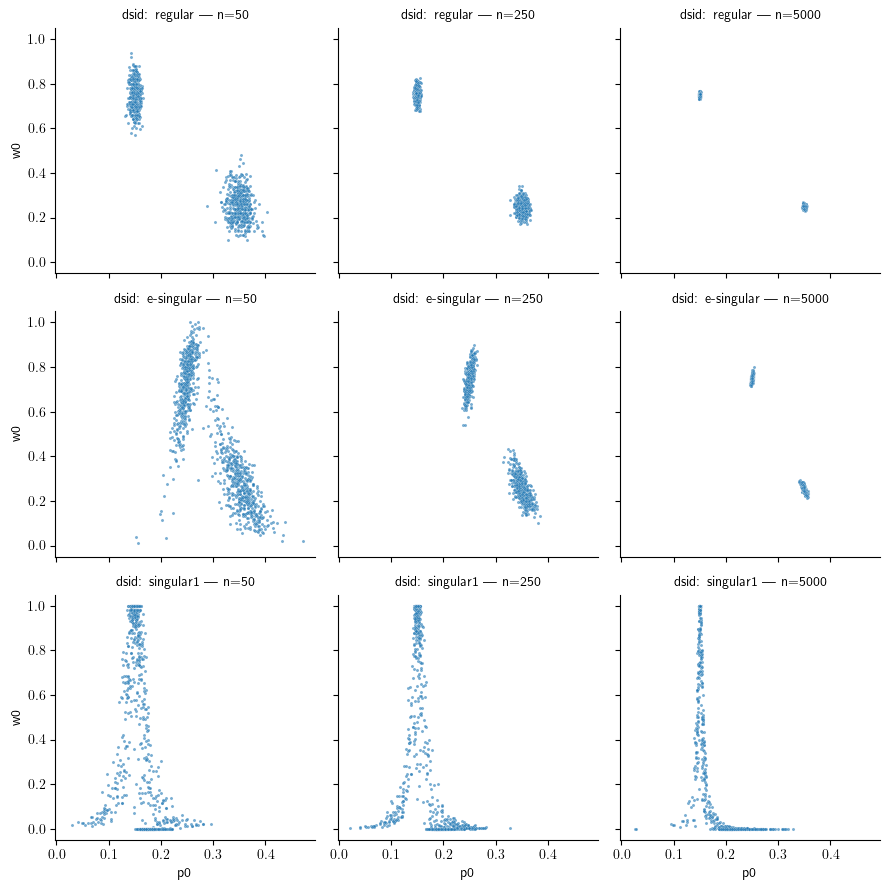

In [13]:
# Create FacetGrid
g = sns.FacetGrid(mles_df, row='dsid', col='n', height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, 'p0', 'w0', alpha=0.6, s=5)

# Add labels and formatting
g.set_axis_labels('p0', 'w0')
g.set_titles(row_template='dsid: {row_name}', col_template='n={col_name}')


plt.savefig(Path(f'./mle/conc_no_contours_p0_w0.png'), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [7]:
def clean_for_plotting(arr, method='percentile', threshold=1000, 
                      percentile=95, handle_nan=True, clip=True):
    """
    Universal cleaning function for plotting
    
    Parameters:
    -----------
    arr : array-like
    method : 'percentile' or 'threshold'
        How to determine replacement values
    threshold : float
        For 'threshold' method: distance from min/max
    percentile : float
        For 'percentile' method: which percentile to use
    handle_nan : bool
        Whether to replace NaN
    clip : bool
        Whether to clip to [min, max] range
    """
    arr = np.asarray(arr, dtype=float).copy()
    
    finite_mask = np.isfinite(arr)
    
    if not np.any(finite_mask):
        return np.zeros_like(arr)
    
    finite_values = arr[finite_mask]
    
    if method == 'percentile':
        low_val = np.percentile(finite_values, 100 - percentile)
        high_val = np.percentile(finite_values, percentile)
        value_range = high_val - low_val
        margin = max(value_range * 0.1, abs(high_val) * 0.01, 1.0)
        replacement_low = low_val - margin
        replacement_high = high_val + margin
    else:  # threshold
        finite_min = finite_values.min()
        finite_max = finite_values.max()
        replacement_low = finite_min - threshold
        replacement_high = finite_max + threshold
    
    # Replace infinities
    arr = np.where(np.isneginf(arr), replacement_low, arr)
    arr = np.where(np.isposinf(arr), replacement_high, arr)
    
    if handle_nan:
        arr = np.where(np.isnan(arr), replacement_high, arr)
    
    if clip:
        arr = np.clip(arr, replacement_low, replacement_high)
    
    return arr

In [8]:
truth=[0.35, 0.15, 0.75, 0.25]
kk = create_mixbinom_profile_kl(n_components=2, n_trials=100,
                                    truth=truth,
                                    x_param={"name":"probs", "index":0},
                                    y_param={"name":"probs", "index":1})

print(kk(np.linspace(0,1, 25), np.linspace(0,1, 25)))

[ 0.         38.62815071 20.97081597 12.06326388  6.8481132   3.74433726
  2.05939605  1.43596462  1.67374637  2.65795178  4.32663732  6.65488997
  9.6475382  13.33705336 17.78552678 23.09097673 29.39959692 36.89184947
 44.65572175 48.0484293  45.75023676 53.46694449 29.60948029  0.17842807
         inf]


datasets :   0%|          | 0/3 [00:00<?, ?it/s]

regular figures:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component
/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component
/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component


e-singular figures:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component
/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component
/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component


singular1 figures:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component
/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component
/Users/ashrafahmed/workspace/singular-learning-theory/code/python/sklearn_extensions/mixture/_binomial.py:197: RuntimeWarning: divide by zero encountered in log
  flat: returna the probilities not just each component


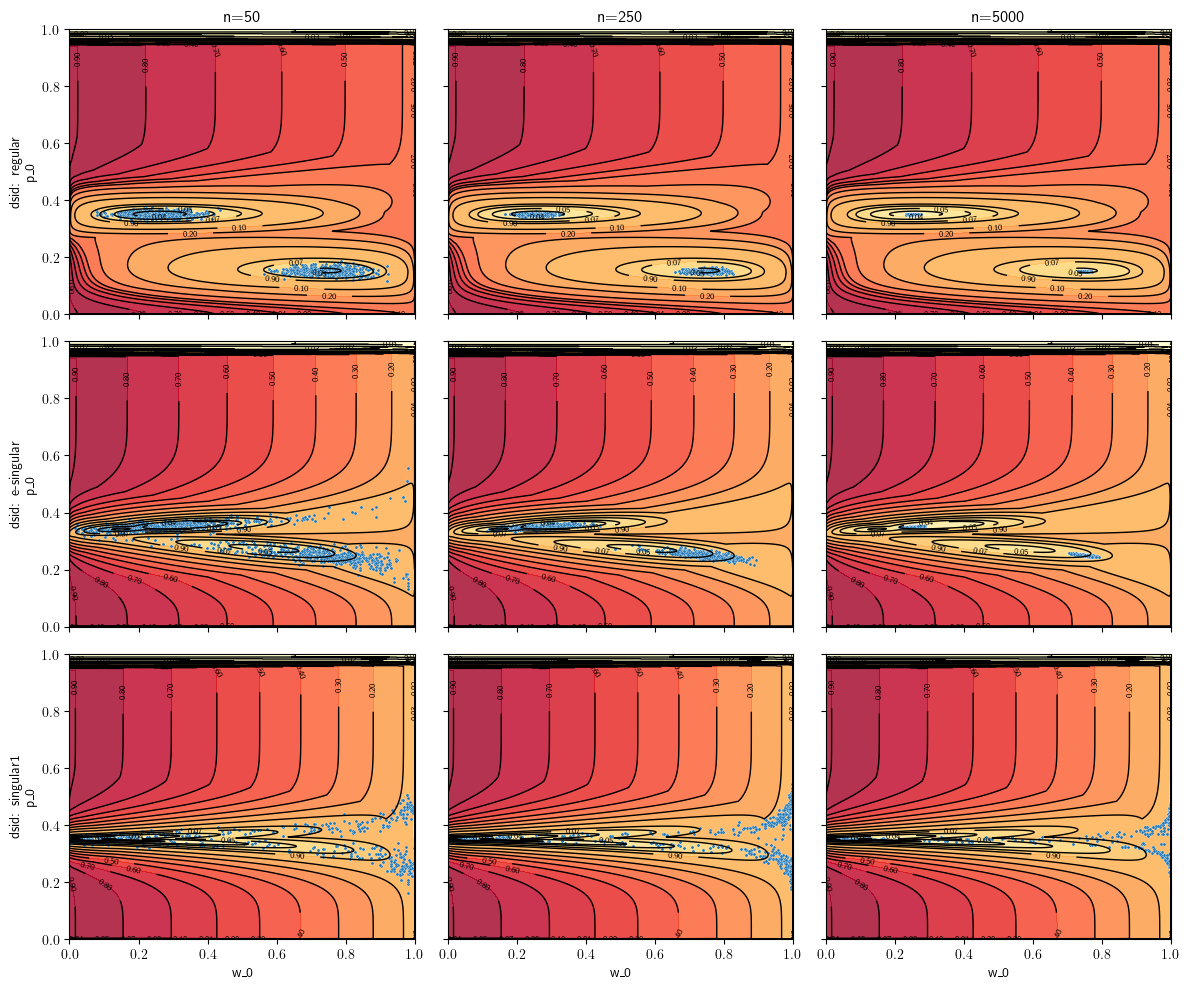

In [24]:
# from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_mles_on_kl(mles_df, profile_kl,
                    plot_options={}, profile_options={}):
    plot_options = {
        "quantiles": np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.9, 0.1, 0.2, 0.3, 0.4, 0.5, .6, .7, 0.8, 0.9, 0.99]),
        # "colors": ['#808080', '#A0A0A0', '#C0C0C0'],
        "figsize": (16,6),
        "linewidths": 2.0,
        "cmap": "magma",
        "line_colors": "black",
        "label_fontsize": 1000
    } | plot_options

    profile_options={
        "grid_size": 100
    } | profile_options
    
    # Get unique values for facets
    dsids = mles_df['dsid'].unique()
    sample_sizes = sorted(mles_df['n'].unique())

    n_rows = len(dsids)
    n_cols = len(sample_sizes)
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True, sharey=True)

    # Plot each panel
    for i, dsid in enumerate(tqdm(dsids, desc=f"datasets ")):
    # for i, dsid in enumerate(dsids):
        dgp = dgps.query(f"dsid=='{dsid}'")
        truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
        height = profile_kl(n_components=n_components, n_trials=n_trials, truth=truth,
                            x_param={"name":"weights", "index":0},
                            y_param={"name":"probs", "index":1},
                            profile_grid_size=profile_options["grid_size"])

        for j, n in enumerate(tqdm(sample_sizes, desc=f"{dsid} figures")):
            ax = axes[i, j]
            
            # Filter data for this combination
            subset = mles_df[(mles_df['dsid'] == dsid) & (mles_df['n'] == n)]
    
           # 1. computed profile KL values
            x = np.linspace(0, 1, 1000)
            y = np.linspace(0, 1, 1000)
            X, Y = np.meshgrid(x, y)
            Z = height(X,Y)

            # compoute contour levels for the quantiles
            # Z = clean_for_plotting(height(X,Y), method='percentile', percentile=0.999)
            levels = np.unique(np.quantile(Z, plot_options["quantiles"]))

            # align contours with levels
            n_levels = len(levels)
            cmap = plt.get_cmap("YlOrRd")
            colors = [cmap(q) for q in np.linspace(0, 1, n_levels)]
        
            cs = ax.contourf(X, Y, Z, levels=levels, colors=colors, alpha=0.8, extend="both")
            cs_lines = ax.contour(X, Y,  Z, levels=levels, colors="black", linewidths=1)
            # Create a dictionary mapping each level to its corresponding quantile value
            fmt = {}
            for l, level in enumerate(levels):
                if l < len(plot_options["quantiles"]):
                    # Just show the quantile value (e.g., "0.95")
                    fmt[level] = f"{plot_options["quantiles"][l]:.2f}"
    
            # Apply the custom labels
            ax.clabel(cs_lines, fontsize=6, inline=True, fmt=fmt, inline_spacing=10, colors="black", use_clabeltext=True)
            
            # Scatter plot
            sns.scatterplot(data=subset, x='w0', y='p1', ax=ax, alpha=1, s=5)
    
            # Add title
            if i == 0:
                ax.set_title(f'n={n}', fontweight='bold')
            if j == 0:
                ax.set_ylabel(f'dsid: {dsid}\np_0', fontweight='bold')
            else:
                ax.set_ylabel('p_0')
            
            if i == n_rows - 1:
                ax.set_xlabel('w_0')
            else:
                ax.set_xlabel('')
            # break
        # break
    return fig, axes


fig, axes = plot_mles_on_kl(mles_df, profile_kl=create_mixbinom_profile_kl, profile_options={"grid_size": 20})
mles_with_kl_file = Path(f'{basedir}/mle/mles_with_kl.png')
if mles_with_kl_file.parent: # create parents dir if not already
    mles_with_kl_file.parent.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
fig.savefig(mles_with_kl_file, dpi=600, bbox_inches='tight')
plt.show()

In [18]:
class SetType(Enum):
    Point = 1
    AlgebraicVariety = 2


class MetricKind(Enum):
    Euclidean = 1
    Mahalanobis = 2

class Point:
    def __init__(self, q: NDArray[np.float_]):
        self.q = q
        
    def create_relative_metric(kind: MetricKind) -> Callable[NDArray[np.float_], NDArray[np.float_]]:
        match kind:
            case Mahalanobis:
                pass
            case _: # default to euclidean distance
                return def dist(p: NDArray[np.float_]) -> NDArray[np.float_]:
                    return np.sqrt(np.linalg.norm(self.p - self.q))
            

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn_ext.profile_likelihood import create_profile_likelihood

param_linespaces = {pname:(0, 1, 100) for pname, p in mle_detail.items()}
profile_ll = create_profile_likelihood(model=BinomialMixture(n_components=2,
                                                             n_trials=n_trials,
                                                             tol=1e-6,
                                                             enforce_ordering=False),
                                       random_state=rng,
                                       X=X)
start, stop, num = param_linespaces["w0"]
x=np.linspace(start=start, stop=stop, num=num).reshape((num,1))

plls, fits = profile_ll(fixed_params=[("weights_", 0)], fixed_values=x)
# print(np.round(fits, 3))
plt.plot(x.flatten(), plls)

In [ ]:
from sklearn_ext.confidence_regions import confidence_estimates
from sklearn_ext.confidence_regions.gaussian import GaussianCRProvider, CovarianceProvider
from sklearn_ext.confidence_regions.bootstrap import BootstrapCRProviderFactory

def point_estimator_factory(
    # max_iter=10**3, tol=1e-3, n_init=50
):
    def estimator(data):
        model=BinomialMixture(n_components=2, n_trials=n_trials
                              # , max_iter=10**3, tol=10**3, n_init=50
                             )
        model.fit(data)
        model._enforce_ordering()
        return model.point_estimate()

    return estimator


cov_provider = CovarianceProvider(fisher_mat = model.fisher_matrix(data))
bootstrap_provider_factory = BootstrapCRProviderFactory(data=data, 
                                                point_estimator=point_estimator_factory(), 
                                                n_params=len(truth), 
                                                n_iterations=10**3)

cr_providers = [
    GaussianCRProvider(mle=mle, cov_provider=cov_provider),
    bootstrap_provider_factory.new_provider()
]

pp_data, cr_data = confidence_estimates(truth=truth,
                     mle=mle_detail,
                     cov_provider=cov_provider,
                     cr_providers=cr_providers,
                     data=data)

In [ ]:
cr_data.round(3)

In [ ]:
from sklearn_ext.mixture import binommix_logpmf

def ell_for_likelihood_pair(mle, obs, apply_params_constraints=None):
    """
    Gets a likelihood profile function that one can evalute on a grid where nuisance variables are fixed to the mle.
    Current implementation only supports fixed number of trials across samples
    mle: a numpy 1D array for the mle parameter value to be fixed
    obs: a numpy 2D array, first column for observations, second column for number of trials
    """
    xdata = obs.iloc[:,0]
    w_dim = len(mle) # dimension of parameter space
    n_trials=obs.iloc[0,1]
    def ell_on_grid(xindex, yindex, x, y):
        """
        computes the profile likelihood function for parameters with index i,j with values x, y
        xindex: integer for index of the x term in the param tuple
        yindex: integer index of the y term in the param tuple
        x: a numpy 1D array for values of the xindex parmaeter
        y: a numpy 1D array for values of the yindex parmaeter
        """
        mle_cond = np.array(mle)
        mle_cond[xindex]=x
        mle_cond[yindex]=y
        mle_cond = apply_params_constraints(w_new=mle_cond, w_old=mle)
        params_weights = mle_cond[:int(w_dim/2)]
        params_probs = mle_cond[int(w_dim/2):]

        # print(f"after fixed nuisance, i={xindex},j={yindex}, mle={mle}, mle_cond={mle_cond}, x={x}, y={y}.")

        values = binommix_logpmf(x=xdata,
                              n_trials=n_trials, 
                              params_weights=params_weights,
                              params_probs=params_probs,
                              flat=True)
        # print(f"values={values}")
        return values
        
    return ell_on_grid


def likelihood_slices(ell, param_pairs, param_ticks):
    results = {}
    for pindex, pair in enumerate(param_pairs):
        i = pair[0]
        j = pair[1]
        x = param_ticks[i]
        y = param_ticks[j]
        X, Y = np.meshgrid(x, y)

        h = np.zeros(X.shape)
        for index in range(h.shape[0]):
            for sindex in range(h.shape[1]):
                h[index, sindex]=ell(xindex=i, yindex=j, x=X[index, sindex], y=Y[index, sindex])
        results[pindex] = {
            "param": (i,j),
            "ticks": (x,y),
            "x": X,
            "y": Y,
            "z": h
        }

    return results

def apply_params_constraints(w_new, w_old):
    """
    Enforces constraints when changing parameters value for profile likelihood.
    This is a typical case in mixture models where the weights must add to 1
    """
    d = len(w_new)
    if np.all(w_new[:int(d/2)] == w_old[:int(d/2)]):
        return w_new # no changes made, no constraints to enforce
    elif np.all(w_new[:int(d/2)] != w_old[:int(d/2)]):
        raise "One of the weights must be fixed" # don't allow the profile likelihood to adjust all weights
    else:
        w_new[int(d/2)-1]=1-np.sum(w_new[:int(d/2)-1]) # enforce constraints. it is assumed that the last weight is the one enforcing additivtiy unity

    return w_new

In [13]:
def slices_for_dataset(dsid, ss_steps, param_pairs, param_ticks):
    """
    Will plot the likelihood slices using samples of varying sizes (as per the ss_steps schedule)
    """
    num_components = 2
    w_dim = num_components*2
    obs=obs_df[[f"x_{dsid}", "n_trials"]]

    results = {}
    for ss in [10, 100, 1000]:
        data=obs.iloc[0:ss,]
        n_trials=data.iloc[0,1]
        
        bmm = BinomialMixture(n_components=2, n_trials=n_trials)
        bmm.fit(data)
        bmm._enforce_ordering() 
        mle = np.zeros(w_dim)
        mle[:int(w_dim/2)]=bmm.weights_
        mle[int(w_dim/2):]=bmm.probs_
                
                
                
        # plot_params_layout[1] = 1-plot_params_layout[0]
        ell = ell_for_likelihood_pair(mle=mle, 
                                      obs=data, 
                                      apply_params_constraints=apply_params_constraints)
        
        slices = likelihood_slices(ell, param_pairs, param_ticks)
        results[ss] = {
            "slices": slices,
            "mle": mle
        }
        print(f"Created slice for dataset {dsid} with sample size {ss}, mle used {mle}")

    return results

In [14]:
def plot_slices(slices, mle, truth, plot_options={}
                # plot_params_layout,
                # plot_subplot_transpose=False, 
                # plot_levels_quantiles=np.linspace(0, 1, 15),
                # plot_colors=['#808080', '#A0A0A0', '#C0C0C0']
               ):
    """
    ell: a profile likelihood function taking x_index: int, y_index: int, x: 1D numpy array, y: 1D numpy array
         that returns an a scalar for the likelihood at coordinates (x,y) with the rest of parameters fixed

    plot_param_layout: list of np.arange for plotting for each parameter ell to be evaluated on.
    plot_subplot_transpose: boolean for whether or not to flip the x, y axis in each subplot, default to False.
    plot_levels: the contour levels to plot
    skip_pair: we should skip a given pair. This is needed since in mixture models, one of the weights is constraint
    """
    plot_options = {
        "quantiles": np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.9, 0.1, 0.25, 0.5, .65, .75, 0.95, 0.965, 0.99]),
        # "colors": ['#808080', '#A0A0A0', '#C0C0C0'],
        "figsize": (16,6),
        "linewidths": 2.0,
        "cmap": "magma",
        "line_colors": "black",
        "label_fontsize": 10
    } | plot_options

    ncols = len(slices)
    fig, axes = plt.subplots(ncols=ncols, nrows=1, figsize=plot_options["figsize"])
    axes = axes.flatten() # flatten for easy iteration
    for k,v in slices.items():
    # for pindex, pair in enumerate(param_pairs):
        i,j = v["param"]
        x,y = v["ticks"]
        z = v["z"]

        # clean up -Inf likelihood values and compute levels
        z = cleanp(z)
        levels = np.unique(np.quantile(z, plot_options["quantiles"]))
        # Create colors for each interval between levels
        n_levels = len(levels)
        cmap = plt.get_cmap(plot_options["cmap"])
        colors = [cmap(q) for q in np.linspace(0, 1, n_levels)]
    
        cs = axes[k].contourf(x, y, z, levels=levels, colors=colors, alpha=0.8, extend="both")
        # plt.colorbar(cs)
        cs_lines = axes[k].contour(x, y,  z, levels=levels, colors=plot_options["line_colors"], linewidths=plot_options["linewidths"])
        # Create a dictionary mapping each level to its corresponding quantile value
        fmt = {}
        for l, level in enumerate(levels):
            if l < len(plot_options["quantiles"]):
                # Just show the quantile value (e.g., "0.95")
                fmt[level] = f"{plot_options["quantiles"][l]:.2f}"

        # Apply the custom labels
        axes[k].clabel(cs_lines, fontsize=8, inline=True, fmt=fmt, inline_spacing=10,
                      colors=plot_options.get("clabel_color", "black"),
                      use_clabeltext=True)

        # Set axis labels with custom font size
        labels = plot_options.get("param_labels", {i: i, j: j})
        axes[k].set_xlabel(labels[i], fontsize=plot_options["label_fontsize"])
        axes[k].set_ylabel(labels[j], fontsize=plot_options["label_fontsize"])

        if mle is not None:
            axes[k].plot(mle[i], mle[j], 
                       marker=plot_options.get("mle_marker", "o"),
                       markersize=plot_options.get("mle_markersize", 8),
                       color=plot_options.get("mle_color", "green"),
                       label=plot_options.get("mle_label", "MLE"))

        if truth is not None:
            axes[k].plot(truth[i], truth[j], 
                         marker=plot_options.get("truth_marker", "x"),
                         markersize=plot_options.get("truth_markersize", 8),
                         color=plot_options.get("truth_color", "red"),
                         label=plot_options.get("true_label", "TRUE"))

        # axes[k].set_title(
    return fig

def plot_all_slices(slices, truth, plot_options):
    figs = {}
    for k,v in slices.items():
        figs[k] = plot_slices(slices=v["slices"], mle=v["mle"], truth=truth, plot_options=plot_options)
        figs[k].suptitle(f"n={k}, truth={truth}")
    return figs

def has_duplicates_seen(arr):
    seen = set()
    for item in arr:
        if item in seen:
            return True
        seen.add(item)
    return False

In [15]:
dsid=0
dgp = dgps.query(f"dsid=={dsid}")
dgp_n_trials = dgp["n_trials"].unique().item()
dgp_weights = dgp[["rho1", "rho2"]].iloc[0].tolist()
dgp_probs = dgp[["p1", "p2"]].iloc[0].tolist()
truth = dgp_weights+dgp_probs

all_slices = slices_for_dataset(dsid=dsid, ss_steps=ss_steps, 
                                param_pairs=[(2,0), (3,0), (3,2)],
                                param_ticks={
                                    0: np.linspace(0, 1, num=200),
                                    2: np.linspace(0, 1, num=200),
                                    3: np.linspace(0, 1, num=200)
                                })

print(f"prepared {len(all_slices)} slices")
print(f"w0={truth}, n={dgp_n_trials}")

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/sklearn_ext/mixture/_binomial_mixture.py:49: RuntimeWarning: divide by zero encountered in log
  total = logsumexp(result + np.log(params_weights), axis=1)


Created slice for dataset 0 with sample size 10, mle used [0.51725675 0.48274325 0.40640263 0.32892328]


/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/sklearn_ext/mixture/_binomial_mixture.py:49: RuntimeWarning: divide by zero encountered in log
  total = logsumexp(result + np.log(params_weights), axis=1)


Created slice for dataset 0 with sample size 100, mle used [0.75362522 0.24637478 0.35132724 0.20956255]


/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/sklearn_ext/mixture/_binomial_mixture.py:49: RuntimeWarning: divide by zero encountered in log
  total = logsumexp(result + np.log(params_weights), axis=1)


Created slice for dataset 0 with sample size 1000, mle used [0.77644531 0.22355469 0.35013211 0.20389448]
prepared 3 slices
w0=[0.75, 0.25, 0.35, 0.2], n=100


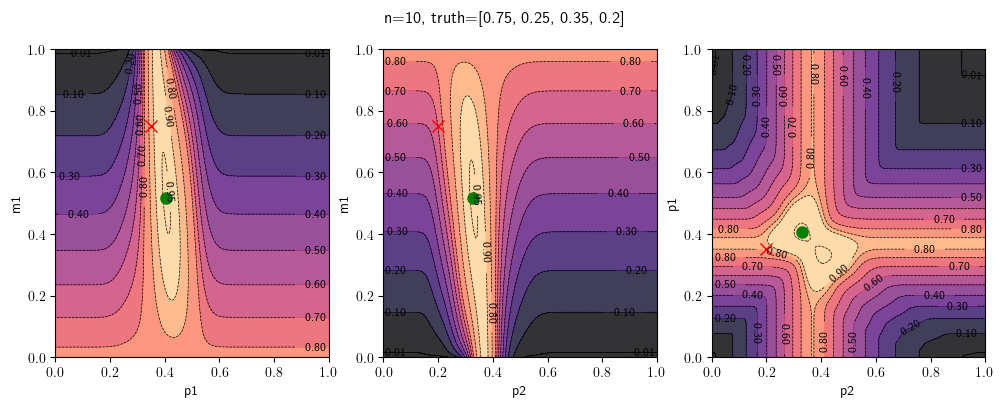

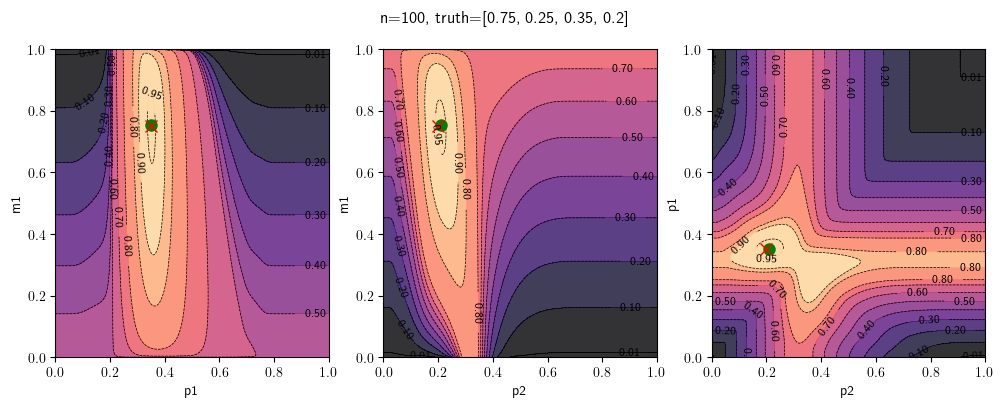

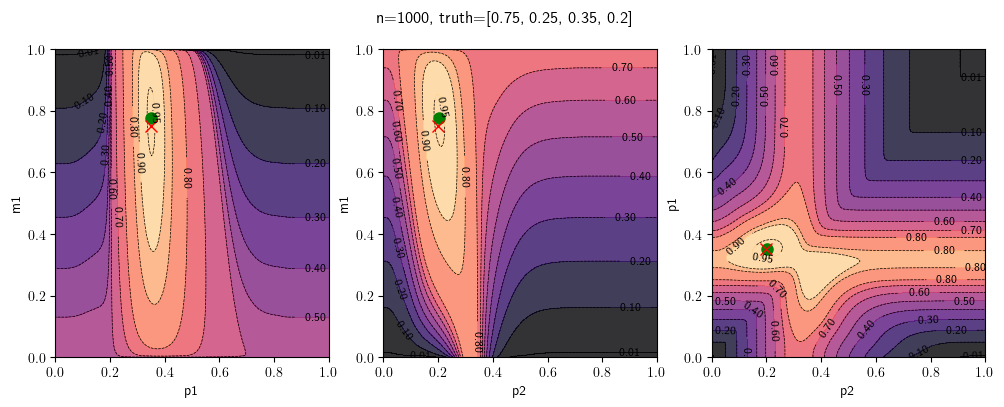

In [17]:
figs = plot_all_slices(slices=all_slices,
                      truth=truth,
                      plot_options={
                          "title": f"dataset={dsid}, w0=[{truth}], n={dgp_n_trials}",
                          "quantiles":np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, .8, 0.8, 0.9, 0.95, 0.995]),
                          "figsize": (12, 4),
                          "linewidths": 0.5,
                          "param_labels": {0: "m1",
                                           1: "m2",
                                           2: "p1",
                                           3: "p2"},
                          "title": f"truth={truth}"
                      })

for k, fig in figs.items():
    fig.savefig(f'likelihood_slices_{dsid}_{k}', dpi=300)

In [ ]:
figs[1000]

In [ ]:
n_replications = 1000 # to visualize the true mle sampling distribution, let's generate K trials

# we will save the results so we don't have to spend a lot of time on this
repls_pathstr = "./binomix/ds{dsid}_ss{ss}_repls.csv"

for dsid in datasets:
    for ss in ss_steps:
        repls_file = Path(repls_pathstr.format(dsid=dsid, ss=ss))
        if repls_file.exists(): # check if this data has already been generated
            print(f"File {repls_file} exists, skipping trials creation!.")
        else:
            if repls_file.parent: # create parents dir if not already
                repls_file.parent.mkdir(parents=True, exist_ok=True)
        
            repls = {}
    
            dgp = dgps.query(f"dsid=={dsid}")
            n_trials = dgp["n_trials"].unique().item()
            weights = dgp[["rho1", "rho2"]].iloc[0].tolist()
            probs = dgp[["p1", "p2"]].iloc[0].tolist()
            dd = BinomialMixture(n_components=2, weights_init=weights, probs_init=probs, n_trials=n_trials)
    
            repls["n_trials"] = np.ones(ss, dtype=int)*n_trials
            for k in tqdm(range(0, n_replications), desc=f"dataset {dsid} replications"):
                samples = dd.sample(n_samples=ss)
                repls[f"x_{k}"] = samples[0].astype(int).tolist()
    
            repls_df = pd.DataFrame(repls)
            repls_df.to_csv(repls_file)
            
            print(f"Created {repls_file} with {n_replications} for {len(datasets)} data sets!.")

In [ ]:
# compute the mle fit for each trial to be plotted to study the true MLE distribution
def compute_mle(x_obs, max_iter=10**8, tol=10e-6):
    # Fit main GMM
    bmm = BinomialMixture(n_components=2,
                          max_iter=max_iter, 
                          tol=tol,
                          n_init=50)

    bmm.fit(x_obs)
    bmm._enforce_ordering() 
    mle = {
        "p1": bmm.probs_[0],
        "p2": bmm.probs_[1], 
        "rho1": bmm.weights_[0],
        "rho2": bmm.weights_[1]
    }
    return mle, bmm


# we will save the results so we don't have to spend a lot of time on this
repls_mle_file = Path("./binomix/repls_mle.csv")
if repls_mle_file.exists(): # check if this data has already been generated
    print(f"File {repls_mle_file} exists, skipping trials mle estimates!.")
else:
    if repls_mle_file.parent: # create parents dir if not already
        repls_mle_file.parent.mkdir(parents=True, exist_ok=True)

    repls_mle={"repl": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "dsid": [], "ss": [], "n_trials": []}
    for dsid in datasets:
        for ss in ss_steps:
            repls = pd.read_csv(repls_pathstr.format(dsid=dsid, ss=ss))
            for k in tqdm(range(0, n_replications), desc=f"mle fit for dataset {dsid}, ss={ss}"):
                X = repls[[f"x_{k}", "n_trials" ]]
                estimate, _ = compute_mle(x_obs=X)
                assert estimate["p1"] >= estimate["p2"], f"p1={estimate["p1"]} < p2={estimate["p2"]}"
                repls_mle["repl"].append(k)
                repls_mle["rho1"].append(estimate["rho1"])
                repls_mle["rho2"].append(estimate["rho2"])
                repls_mle["p1"].append(estimate["p1"])
                repls_mle["p2"].append(estimate["p2"])
                repls_mle["dsid"].append(dsid)
                repls_mle["ss"].append(ss)
                repls_mle["n_trials"].append(X["n_trials"].unique().item())
    
    pd.DataFrame(repls_mle).to_csv(repls_mle_file)
    print(f"File {repls_mle_file} created!")

repls_mle_df = pd.read_csv(repls_mle_file)
repls_mle_df.head()
repls_mle_df

In [ ]:
# fitting observations themselves
mle_est_file = Path("./binomix/mle_est.csv")
if mle_est_file.exists(): # check if this data has already been generated
    print(f"File {mle_est_file} exists, skipping mle estimation.")
else:
    if mle_est_file.parent: # create parents dir if not already
        mle_est_file.parent.mkdir(parents=True, exist_ok=True)
    mle_est={"rho1": [], "rho2":[], "p1":[], "p2":[], "dsid": [], "ss": [], "observed_fisher_matrix": []}
    for dsid in datasets:
        for ss in ss_steps:
            X = obs_df[[f"x_{dsid}", "n_trials"]]
            x_obs = X[0:ss]
            estimate, bmm = compute_mle(x_obs=x_obs)
            assert estimate["p1"] >= estimate["p2"], f"p1={estimate["p1"]} < p2={estimate["p2"]}"
            mle_est["rho1"].append(estimate["rho1"])
            mle_est["rho2"].append(estimate["rho2"])
            mle_est["p1"].append(estimate["p1"])
            mle_est["p2"].append(estimate["p2"])
            mle_est["dsid"].append(dsid)
            mle_est["ss"].append(ss)
            fisher_matrix = bmm.fisher_matrix(x_obs)
            # print(fisher_matrix)
            # print(mle_est)
            mle_est["observed_fisher_matrix"].append(fisher_matrix.flatten()) #flatten it to save it in csv, we will reshape when processing

    pd.DataFrame(mle_est).to_csv(mle_est_file)

mle_es_df=pd.read_csv(mle_est_file)
mle_es_df

In [ ]:
from scipy.stats import chi2

def compute_ellipse_parameters(center, cov_matrix, confidence_level=0.95):
    """
    Compute ellipse parameters from center and 2×2 covariance matrix.
    
    Parameters:
    -----------
    center : array-like (2,)
        Center coordinates [x, y]
    cov_matrix : numpy array (2 × 2)  
        Covariance matrix for the parameter pair
    confidence_level : float
        Confidence level (default 0.95)
    
    Returns:
    --------
    dict with ellipse parameters
    """
    
    # Chi-square critical value for 2 DOF
    chi2_critical = chi2.ppf(confidence_level, df=2)
    
    # Eigendecomposition of covariance matrix
    eigenvals, eigenvecs = np.linalg.eigh(cov_matrix)
    
    # Sort eigenvalues (largest first)
    idx = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]
    
    # Ellipse semi-axes (scaled by chi-square critical value)
    width = 2 * np.sqrt(chi2_critical * eigenvals[0])   # Major axis
    height = 2 * np.sqrt(chi2_critical * eigenvals[1])  # Minor axis
    
    # Rotation angle (in degrees)
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    
    return {
        'center': center,
        'width': width,
        'height': height,
        'angle': angle,
        'eigenvals': eigenvals,
        'eigenvecs': eigenvecs,
        'chi2_critical': chi2_critical
    }
    
def marginalize_fisher_matrix(fisher_matrix, param_indices):
    """
    Extract marginal covariance matrix for a subset of parameters.
    
    Parameters:
    -----------
    fisher_matrix : numpy array (p × p)
        Full observed Fisher information matrix
    param_indices : list or tuple
        Indices of parameters to keep (e.g., [0, 2] for params 0 and 2)
    
    Returns:
    --------
    marginal_cov : numpy array (2 × 2)
        Marginal covariance matrix for the selected parameter pair
    """
    
    # Invert Fisher matrix to get full covariance
    try:
        full_cov = np.linalg.inv(fisher_matrix)
    except np.linalg.LinAlgError as e:
        raise ValueError(f"Fisher matrix is singular - cannot invert, cause{e}")
    
    # Extract marginal covariance submatrix
    marginal_cov = full_cov[np.ix_(param_indices, param_indices)]
    
    return marginal_cov

def add_fisher_ellipse(ax, 
                       fisher_matrix, 
                       center, 
                       param_indices, 
                       confidence_level=0.95, **ellipse_kwargs):
    """
    Add confidence ellipse to axis for a specific parameter pair.
    
    Parameters:
    -----------
    ax : matplotlib axis
    fisher_matrix : numpy array (3 × 3)
        Full Fisher information matrix
    mle_estimates : array-like (3,)
        MLE estimates for all 3 parameters
    param_indices : list or tuple (2,)
        Which parameters to plot (e.g., [0, 1], [0, 2], [1, 2])
    confidence_level : float
        Confidence level
    **ellipse_kwargs : dict
        Additional styling for ellipse
    """
    # Get marginal covariance for this parameter pair
    marginal_cov = marginalize_fisher_matrix(fisher_matrix, param_indices)
    
    # Center coordinates for this pair
    # center = mle_estimates[param_indices]
    
    # Compute ellipse parameters
    ellipse_params = compute_ellipse_parameters(center, marginal_cov, confidence_level)
    
    # Default ellipse styling
    ellipse_defaults = {
        'facecolor': 'red',
        'alpha': 0.2,
        'edgecolor': 'red',
        'linewidth': 2,
        'label': f'{int(confidence_level*100)}% Fisher CI'
    }
    ellipse_defaults.update(ellipse_kwargs)
    
    # Create and add ellipse
    ellipse = Ellipse(
        xy=ellipse_params['center'],
        width=ellipse_params['width'],
        height=ellipse_params['height'],
        angle=ellipse_params['angle'],
        **ellipse_defaults
    )
    ax.add_patch(ellipse)
    
    return ellipse, ellipse_params

In [ ]:
from matplotlib.patches import Ellipse

poles = {
    "dsid": [1, 1, 1],
    "xpole": [ [[0.3, 0.3],[0, 0.5]], [[0.3, 0.3],[0, 1]], [[0.3, 0.3],[0, 1]] ],
    "ypole": [ [[0, 0.5], [0.3, 0.3]], [[0, .5], [0, 0]], [[0, 0.5], [1, 1]] ],
    "xvar": ["p1", "p1", "p2"],
    "yvar": ["p2", "rho1", "rho1"],
}

poles["dsid"].extend([2, 2, 2])
poles["xpole"].extend([ [[0.3, 0.3],[0, 0.5]], [[0.3, 0.3],[0, 1]], [[0.3, 0.3],[0, 1]] ])
poles["ypole"].extend([ [[0, 0.5], [0.3, 0.3]], [[0, .5], [0, 0]], [[0, 0.5], [1, 1]] ])
poles["xvar"].extend(["p1", "p1", "p2"])

poles["yvar"].extend(["p2", "rho1", "rho1"])
poles = pd.DataFrame(poles)

def plot_mle_and_confidence_intervals(ddf, dgps, confidence_level=0.95):
    datasets = ddf["dsid"].unique()
    fig, axes = plt.subplots(
        3, len(datasets), 
        figsize=(4*len(datasets), 12),
        sharex=False,
        sharey=False
    )
    
    pairs = [('p1', 'p2'), ('p1', 'rho1'), ('p2', 'rho1'), ]
    pair_labels = [('$p_1$', '$p_2$'), ('$p_1$', '$\\rho_1$'), ('$p_2$', '$\\rho_1$'), ]
    param_index = {
        "p1": 0,
        "p2": 1,
        "rho1": 2,
        "rho2": 3,
    }

    ss_colors = {
        100: "blue",
        500: "orange",
        1000: "green"
    }
    dsids = sorted(ddf['dsid'].unique())
    
    for i, ((x_var, y_var), (x_label, y_label)) in enumerate(zip(pairs, pair_labels)):
        for j, dsid in enumerate(dsids):
            data_subset = ddf[ddf['dsid'] == dsid]
            
            # Use seaborn scatterplot instead of matplotlib scatter
            sns.scatterplot(data=data_subset, x=x_var, y=y_var, hue="ss",
                           alpha=0.5, s=5, marker='.', ax=axes[i, j], legend=False, palette=default_palette)
    
            # overlay the true parameter
            true_params = data=dgps[dgps["dsid"]==dsid]
            sns.scatterplot(data=true_params, x=x_var, y=y_var, 
                           color='red', marker='x', s=50, alpha=1.0, ax=axes[i, j], legend=False)

            #plotting the pole lines for the set of true parameters
            if j != 0:
                querystr = f"dsid=={dsid} and xvar=='{x_var}' and yvar=='{y_var}'"
                pole = poles.query(querystr)
                xpole = pole["xpole"].item()
                ypole = pole["ypole"].item()
                axes[i,j].plot(xpole[0], xpole[1], color='red', linestyle='-', linewidth=0.5)
                axes[i,j].plot(ypole[0], ypole[1], color='red', linestyle='-', linewidth=0.5)
                
            # overlay the mle estimates
            mles = mle_es_df.query(f"dsid=={dsid}")
            sns.scatterplot(data=mles, x=x_var, y=y_var, hue="ss",
                           marker='o', s=50, alpha=1, ax=axes[i, j], legend=False, palette=default_palette)

            # confidence region curves for the guassian approximation
            for ss in ss_steps:
                mle = mles[mles["ss"]==ss]
                matrix = np.fromstring(mle["observed_fisher_matrix"].item().strip('[]'), sep=' ')
                print(matrix)
                observed_fisher_matrix = matrix.reshape((len(param_index)-1, len(param_index)-1))
                # regularized = fisher_regularizer(observed_fisher_matrix)
                # fixed_xlim = axes[i,j].get_xlim()
                # fixed_ylim = axes[i,j].get_ylim()
                # print(mle)
                add_fisher_ellipse(ax=axes[i,j], 
                                   fisher_matrix=observed_fisher_matrix, 
                                   center=[mle[x_var], mle[y_var]], 
                                   param_indices=[param_index[x_var], param_index[y_var]], 
                                   confidence_level=confidence_level, 
                                   facecolor='none', edgecolor=ss_colors[ss], alpha=1, linewidth=0.5)

                # axes[i,j].set_xlim(fixed_xlim)
                # axes[i,j].set_ylim(fixed_ylim)
            
            axes[i, j].set_xlabel(x_label)
            axes[i, j].set_ylabel(y_label)
            
            if i == 0:
                axes[i, j].set_title(f'{dsid}')
    
    # Create legend elements
    legend_elements = []
    colors = sns.color_palette(n_colors=len(ss_steps))
    # Add hue legend (for different 'n' values)
    for idx, ss in enumerate(ss_steps):
        legend_elements.append(Line2D([0], [0], marker='.', color='w', 
                                     markerfacecolor=colors[idx], markersize=8, 
                                     label=f'ss = {ss}', alpha=0.8))
    
    # overlay true parameters
    legend_elements.append(Line2D([0], [0], marker='x', color='red', 
                                 linestyle='None', markersize=8, 
                                 label='DGP'))

    legend_elements.append(Line2D([0], [0], marker="+", color='red', 
                             linestyle='-', markersize=8, alpha=0.5, 
                             label='true parameters'))

    # overlay mle estimates from obseration
    for idx, ss in enumerate(ss_steps):
        legend_elements.append(Line2D([0], [0], marker='o',
                                     linestyle='None', markersize=6, 
                                      markerfacecolor=colors[idx],
                                     label=f'mle {ss}'))
    
    # Add legend to the figure
    plt.legend(handles=legend_elements, loc='best', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.savefig('binomix/mle_scatter_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_mle_and_confidence_intervals(ddf=repls_mle_df, dgps=dgps, confidence_level=0.95)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your mle_df dataframe
g = sns.pairplot(
    mle_df[["n", "rho1", "p1", "p2"]].rename(columns={
        'n': 'n',
        'rho1': '$\\rho_1$', 
        'p1': '$p_1$', 
        'p2': '$p_2$'
    }), 
    hue='n',
    hue_order=[1000, 500, 100],  # explicit order
    height=4,
    aspect=1,
    diag_kind="hist",
    plot_kws={
        'alpha': 0.5,
        's': 5,
        'marker': '.',
        'linewidth': 0,  # removes edge lines for cleaner look
    },
    diag_kws={
        'alpha': 0.7,
        'bins': 30,  # if using histograms on diagonal
    }
)

# Set axis labels with LaTeX formatting
# g.set_axis_labels('$p_1$', '$\\rho_1$')

plt.show()

In [ ]:
def resample_and_fit(X, random_state, n_samples, max_iter=10**3, tol=10**3, n_init=1):
    try:
        X_boot = resample(X, random_state=random_state, n_samples=n_samples)
        bmm_boot = BinomialMixture(n_components=2, 
                                   tol=tol, 
                                   max_iter=max_iter,
                                   n_init=n_init)
        
        bmm_boot.fit(X_boot)
        
        if not bmm_boot.converged_:
            raise Error(f"Iteration {i} didn't converge!")

        bmm_boot._enforce_ordering() 
    
        mle = {
            "p1": bmm_boot.probs_[0],
            "p2": bmm_boot.probs_[1], 
            "rho1": bmm_boot.weights_[0],
            "rho2": bmm_boot.weights_[1],
            'iteration': i
        }

    except Exception as e:
        print(f"Error in bootstrap iteration {i}: {e}")
        return None

In [ ]:
##### Set the known variances
n_incr = int(n_samples*1/5)
#partition the total samples into 1/10 increments to show case the impact of number of trials on estimates
n_steps = np.arange(n_incr, n_samples+n_incr, n_incr)
estimates_ts = {}

for e in tqdm(range(total_experiments), desc=f"experiment "):
    w0 = dgp_df.loc[f"{e}"]
    x_obs=(data[[f'{e}_x', f"{e}_n"]]).values
    for i in tqdm(range(len(n_steps)), desc=f"trials "):
        nn = n_steps[i]
        estimates = compute_mle(x_obs=x_obs[:nn],
                                n_bootstrap=10000,
                                max_iter=10**3,
                                tol=10e-3)

        if f"dataset_{e}" not in estimates_ts:
            estimates_ts[f"dataset_{e}"] = { "n":[], "p1": [], "p2": [], "rho1": [], "rho2": []}

        ds = estimates_ts.get(f"dataset_{e}")
        ds["n"].append(nn)
        for pname in ["p1", "p2", "rho1", "rho2"]:
            ss = estimates[pname]["bootstraps"]
            ci_upper = estimates[pname]["ci_upper"]
            ci_lower = estimates[pname]["ci_lower"]
            
            ds[pname].append({
                "mle": estimates[pname]["mle"],
                "bootstraps": estimates[pname]["bootstraps"],
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "boot_min": np.min(estimates[pname]["bootstraps"]),
                "boot_max": np.max(estimates[pname]["bootstraps"])
            })

In [ ]:
# Create DataFrame
dsid = f"dataset_2"
w_true = {
    # "rho1": dgp_df.loc["1", ["rho1"]],
    "rho2": dgp_df.loc["1", ["rho2"]],
    "p1": dgp_df.loc["1", ["p1"]],
    "p2": dgp_df.loc["1", ["p2"]]
}

# for i in range(len(estimates_ts[dsid]["rho1"])):
crdata = pd.DataFrame({
    # 'rho1': estimates_ts[dsid]["rho1"][4]["bootstraps"],
    'rho2': estimates_ts[dsid]["rho2"][1]["bootstraps"], 
    'p1': estimates_ts[dsid]["p1"][1]["bootstraps"],
    'p2': estimates_ts[dsid]["p2"][1]["bootstraps"]
})

# fig, axes = visualize_joint_confidence_regions(crdata, 
#                                           true_params=w_true,
#                                           methods=['kde', 'ellipse']
#                                               )  # Focus on key methods
    
# Create pairplot
g = sns.pairplot(crdata,
                 # corner=True,
                 kind="kde",
                 diag_kind='hist',
                 plot_kws={'levels': [0.68, 0.95, 0.995], 
                           'alpha': 0.6,
                           'fill': True} # Filled contours
                )

# g.set(xlim=(0, 1), ylim=(0, 1))
# Customize the plot
g.fig.suptitle(f'Bootstrap confidence regions, n={estimates_ts[dsid]["n"][i]}')
    
    # print(estimates_ts[dsid]["rho2"][1]["ci_lower"])
    # print(estimates_ts[dsid]["rho2"][1]["ci_upper"])

In [ ]:
# Plot the results
def plot_percentile_results(data, pname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    global_min = None
    global_max = None
    for i, dataset in enumerate([f'dataset_{j}' for j in range(0, total_experiments)]):
        ax = axes[i]

        mle = [x["mle"] for x in data[dataset][pname]]
        ci_lower = [x["ci_lower"] for x in data[dataset][pname]]
        ci_upper = [x["ci_upper"] for x in data[dataset][pname]]

        if not global_min:
            global_min = np.min(ci_lower)
        else:
            possible_min = np.min(ci_lower)
            global_min = global_min if global_min < possible_min else possible_min
            
        if not global_max:
            global_max = np.max(ci_upper)
        else:
            possible_max = np.max(ci_upper)
            global_max = global_max if global_max > possible_max else possible_max
        
        x = data[dataset]['n']
        y = mle
        ci_lower = ci_lower
        ci_upper = ci_upper
        
        # Plot estimate
        ax.plot(x, y, 'o-', color='gray', markersize=4)
        
        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color='pink')
        truth = (dgp_df.loc[f"{i}", [pname]]).item()
        # print(f"dataset={dataset}, truth={truth:0.3f}, mle={data[dataset]['mle'][pname]}")
        ax.axhline(y=truth, color='blue', linestyle='-', linewidth=2, alpha=0.8)
        ax.set_title(f'Dataset {i+1} - 95th Percentile')
        ax.set_xlabel('Sample Size')
        ax.set_ylabel(f'{pname} estimate')
        ax.grid(True, alpha=0.3)

    padding = (global_max-global_min)*0.1
    for ax in axes:
        ax.set_ylim(global_min-padding, global_max+padding)
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_percentile_results(data=estimates_ts, pname="p1")

In [ ]:
plot_percentile_results(estimates_ts, pname="p2")

In [ ]:
plot_percentile_results(estimates_ts, pname="rho2")